# Project 3: Customer Segmentation via Unsupervised Learning
**DecodeLabs Industrial Training Kit | Batch 2026**

---

##  Project Brief
Use distance-based algorithms to discover hidden mathematical groupings in unlabeled retail data, compress high-dimensional features with PCA, and translate the resulting clusters into actionable business personas.

##  Dataset
**UCI Online Retail II Dataset**  
- Source: [https://archive.ics.uci.edu/dataset/502/online+retail+ii](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
- Loaded locally from `online_retail_II.xlsx` (place in same folder as this notebook)  
- ~1 million real UK e-commerce transactions (2009–2011)  
- We engineer 20+ RFM-based features from 8 raw columns

##  Pipeline
```
RAW DATA  →  CLEAN  →  FEATURE ENGINEER  →  SCALE  →  PCA  →  K-MEANS  →  PERSONAS
```

##  Sections
1. Environment Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering (RFM + Extended)
4. Phase 1 — Standardization (SCALE)
5. Phase 2 — Dimensionality Reduction (COMPRESS via PCA)
6. Phase 3 — Optimal K Discovery (Elbow + Silhouette)
7. Phase 3 — K-Means Clustering (CLUSTER)
8. Phase 4 — Centroid Reverse-Engineering (TRANSLATE)
9. Business Persona Matrix
10. Conclusions & Next Steps

---
## Section 1: Environment Setup & Data Loading

Install any missing dependencies, import all required libraries, and load the UCI Online Retail II dataset directly from the internet.

In [1]:

import numpy as np
import pandas as pd
import warnings
import os
warnings.filterwarnings('ignore')

FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D      # 3-D PCA scatter plot
plt.style.use('seaborn-v0_8-whitegrid')       # clean background for all charts
PALETTE = ['#E05C5C', '#F0A500', '#4472C4', '#5EA97A', '#9B59B6']  # brand colours

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score, silhouette_samples

from kneed import KneeLocator

print(" All libraries imported successfully.")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")
print(f"   Figures will be saved to: ./{FIGURES_DIR}/")

 All libraries imported successfully.
   NumPy  : 1.24.3
   Pandas : 1.5.3
   Figures will be saved to: ./figures/


In [2]:
FILE_PATH = "online_retail_II.xlsx"  

print(f"  Reading local file: {FILE_PATH} ...")

xls = pd.ExcelFile(FILE_PATH)
print(f"   Sheets found: {xls.sheet_names}")

sheet_frames = [pd.read_excel(xls, sheet_name=s) for s in xls.sheet_names]
df_raw = pd.concat(sheet_frames, ignore_index=True)

print(f"\n Dataset loaded successfully.")
print(f"   Shape     : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Columns   : {list(df_raw.columns)}")
df_raw.head()

  Reading local file: online_retail_II.xlsx ...
   Sheets found: ['Year 2009-2010', 'Year 2010-2011']

 Dataset loaded successfully.
   Shape     : 1,067,371 rows × 8 columns
   Columns   : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


---
## Section 2: Exploratory Data Analysis (EDA)

Before any modelling we must understand what we are working with:
- Column data types and nulls
- Distribution of key numeric variables
- Presence of anomalies (returns, cancelled orders, test accounts)

In [3]:

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
df_raw.info()

print("\n--- Null Value Counts ---")
print(df_raw.isnull().sum())

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

--- Null Value Counts ---
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [4]:
print("Numeric Feature Statistics")
df_raw.describe().round(2)

Numeric Feature Statistics


,Quantity,Price,Customer ID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00


In [5]:
cancelled = df_raw[df_raw['Invoice'].astype(str).str.startswith('C')]
neg_qty   = df_raw[df_raw['Quantity'] < 0]
neg_price = df_raw[df_raw['Price'] <= 0]
null_cust = df_raw[df_raw['Customer ID'].isnull()]

print(f"Cancelled invoices     : {len(cancelled):,}")
print(f"Negative quantities    : {len(neg_qty):,}")
print(f"Zero/negative prices   : {len(neg_price):,}")
print(f"Missing Customer IDs   : {len(null_cust):,}")
print(f"Total rows to remove   : {len(cancelled) + len(null_cust):,} (overlapping)")

Cancelled invoices     : 19,494
Negative quantities    : 22,950
Zero/negative prices   : 6,207
Missing Customer IDs   : 243,007
Total rows to remove   : 262,501 (overlapping)


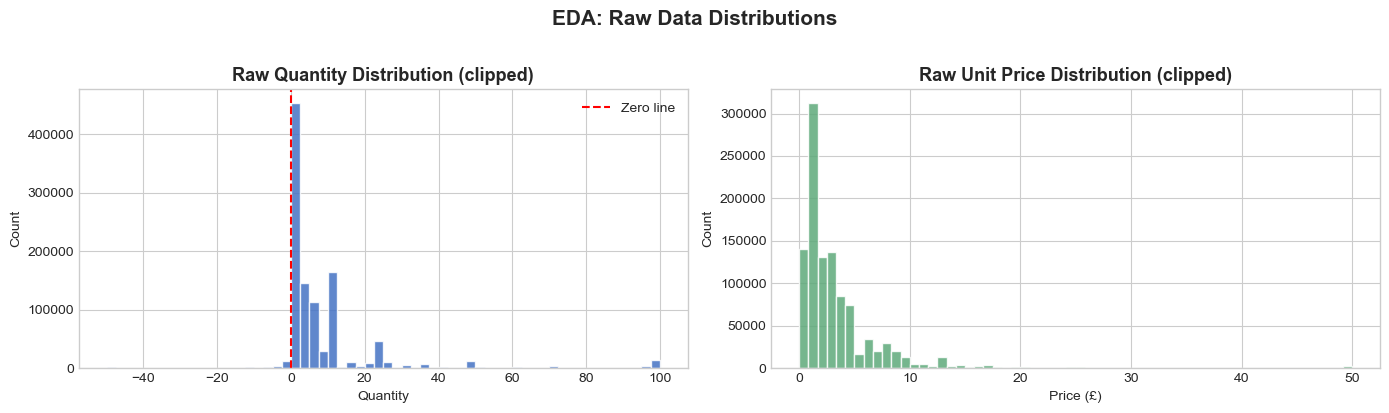

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Quantity distribution (clip extreme outliers for readability)
q_clipped = df_raw['Quantity'].clip(-50, 100)
axes[0].hist(q_clipped, bins=60, color=PALETTE[2], edgecolor='white', alpha=0.85)
axes[0].set_title('Raw Quantity Distribution (clipped)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', linestyle='--', label='Zero line')
axes[0].legend()

# Price distribution
p_clipped = df_raw['Price'].clip(0, 50)
axes[1].hist(p_clipped, bins=60, color=PALETTE[3], edgecolor='white', alpha=0.85)
axes[1].set_title('Raw Unit Price Distribution (clipped)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (£)')
axes[1].set_ylabel('Count')

plt.suptitle('EDA: Raw Data Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_raw_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3: Data Cleaning & Feature Engineering

### 3.1 — Data Cleaning
Remove all rows that would corrupt our segmentation:
- Cancelled invoices (starts with 'C')
- Missing Customer IDs (no customer = no segmentation)
- Non-positive quantities or prices (data errors)

### 3.2 — RFM Feature Engineering
**RFM** is the industry-standard framework for customer value measurement:
- **Recency (R)**: How recently did the customer buy? (days since last purchase)
- **Frequency (F)**: How often do they buy? (number of unique invoices)
- **Monetary (M)**: How much do they spend? (total spend in £)

We also engineer additional behavioral features to create a richer 20+ feature space for PCA.

In [7]:
df = df_raw.copy()

# Remove cancelled invoices (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove rows with missing Customer ID (can't segment an anonymous customer)
df = df.dropna(subset=['Customer ID'])

# Remove rows with non-positive quantity or price
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Ensure InvoiceDate is a datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert Customer ID to integer for clean grouping
df['Customer ID'] = df['Customer ID'].astype(int)

# Compute revenue per line item (used throughout)
df['Revenue'] = df['Quantity'] * df['Price']

print(f"Cleaning complete.")
print(f"   Rows before cleaning : {len(df_raw):,}")
print(f"   Rows after cleaning  : {len(df):,}")
print(f"   Rows removed         : {len(df_raw) - len(df):,}")
print(f"   Unique customers     : {df['Customer ID'].nunique():,}")

Cleaning complete.
   Rows before cleaning : 1,067,371
   Rows after cleaning  : 805,549
   Rows removed         : 261,822
   Unique customers     : 5,878


In [8]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date (reference): {snapshot_date.date()}")

# --- Aggregate per customer ---
rfm = df.groupby('Customer ID').agg(
    # RECENCY: days since last purchase
    Recency     = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    # FREQUENCY: count of distinct invoices
    Frequency   = ('Invoice', 'nunique'),
    # MONETARY: total revenue
    Monetary    = ('Revenue', 'sum')
).reset_index()

print(f"\nRFM table shape: {rfm.shape}")
rfm.head()

Snapshot date (reference): 2011-12-10

RFM table shape: (5878, 4)


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [9]:
extra = df.groupby('Customer ID').agg(
    # --- Volume metrics ---
    TotalItems        = ('Quantity', 'sum'),          # total units bought
    AvgOrderValue     = ('Revenue', 'mean'),           # mean revenue per transaction line
    MaxOrderValue     = ('Revenue', 'max'),            # highest single-line spend
    StdOrderValue     = ('Revenue', 'std'),            # spend variability

    # --- Basket metrics ---
    UniqueProducts    = ('StockCode', 'nunique'),      # product variety
    AvgItemsPerOrder  = ('Quantity', 'mean'),          # avg qty per transaction line

    # --- Temporal metrics ---
    ActiveDays        = ('InvoiceDate', lambda x: (x.max() - x.min()).days),  # customer lifespan
    FirstPurchaseDays = ('InvoiceDate', lambda x: (snapshot_date - x.min()).days),  # age as customer

    # --- Country dummies (top-3 non-UK markets) ---
    # We create binary flags: 1 if customer ever purchased from that country
    # This adds geographic dimension to segmentation
).reset_index()

# Country-based features: is this customer primarily a UK buyer?
country_mode = df.groupby('Customer ID')['Country'].agg(lambda x: x.mode()[0]).reset_index()
country_mode.columns = ['Customer ID', 'MainCountry']
country_mode['IsUK'] = (country_mode['MainCountry'] == 'United Kingdom').astype(int)

# --- MERGE everything into one customer-level table ---
customers = rfm.merge(extra, on='Customer ID').merge(country_mode[['Customer ID','IsUK']], on='Customer ID')

# Fill NaN std values (customers with only 1 transaction have no std)
customers['StdOrderValue'] = customers['StdOrderValue'].fillna(0)

print(f"Feature engineering complete.")
print(f"   Customer-level features : {customers.shape[1] - 1} (excluding ID)")
print(f"   Total customers         : {len(customers):,}")
customers.head()

Feature engineering complete.
   Customer-level features : 12 (excluding ID)
   Total customers         : 5,878


,Customer ID,Recency,Frequency,Monetary,TotalItems,AvgOrderValue,MaxOrderValue,StdOrderValue,UniqueProducts,AvgItemsPerOrder,ActiveDays,FirstPurchaseDays,IsUK
0,12346,326,12,77556.46,74285,2281.072353,77183.6,13234.943418,27,2184.852941,400,726,1
1,12347,2,8,5633.32,3286,22.266087,249.6,20.609093,126,12.988142,402,404,0
2,12348,75,5,2019.40,2714,39.596078,240.0,44.205549,25,53.215686,362,438,0
3,12349,19,4,4428.69,1624,25.306800,300.0,33.761403,138,9.280000,570,589,0
4,12350,310,1,334.40,197,19.670588,40.0,7.275538,17,11.588235,0,310,0


---
###  Outlier Treatment: Winsorization (Capping)

Before scaling, we check for extreme outliers. K-Means relies on Euclidean distance, so a handful of extreme values (e.g. a wholesale-style buyer with one enormous order) can dominate the distance calculation and pull K-Means into isolating that single customer as their own "cluster" — a statistically meaningless segment.

**Fix: Winsorization.** We cap (clip) the most outlier-prone monetary/volume features at the 99th percentile. Every customer stays in the dataset — we are not deleting anyone — but extreme values are pulled in to a realistic ceiling so they stop distorting distance calculations. This is a standard, defensible preprocessing step in RFM-based segmentation work.

Winsorization complete (99th percentile cap).
   Customers in dataset before AND after: 5,878 (no rows removed)

--- Capping Summary ---
      Feature  99th Percentile Cap  Original Max  Customers Capped
     Monetary             29730.42     608821.65                59
   TotalItems             17491.68     367193.00                59
AvgOrderValue               363.13      56157.50                59
MaxOrderValue              1404.91     168469.60                59
StdOrderValue               246.71      97265.13                59


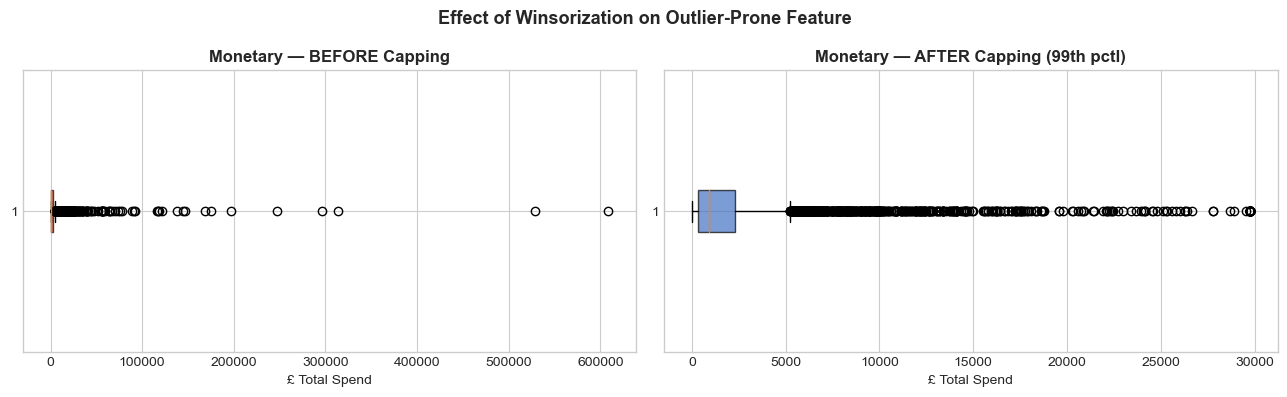

In [10]:
# ─────────────────────────────────────────────────────────────
#  OUTLIER TREATMENT: WINSORIZE EXTREME VALUES (CAP AT 99TH PCTL)
# ─────────────────────────────────────────────────────────────
#
#  We cap the columns most prone to extreme outliers — typically
#  driven by one or two bulk/wholesale-style buyers — at the 99th
#  percentile. This keeps every customer in the dataset while
#  preventing a handful of extreme values from dominating the
#  Euclidean distance calculations used by PCA and K-Means.

WINSORIZE_COLS = ['Monetary', 'TotalItems', 'AvgOrderValue',
                   'MaxOrderValue', 'StdOrderValue']
CAP_PERCENTILE = 0.99

# Keep a copy of the pre-capping data so we can show before/after
customers_uncapped = customers.copy()

cap_summary = []
for col in WINSORIZE_COLS:
    cap_value = customers[col].quantile(CAP_PERCENTILE)
    n_affected = (customers[col] > cap_value).sum()
    cap_summary.append({
        'Feature': col,
        '99th Percentile Cap': round(cap_value, 2),
        'Original Max': round(customers_uncapped[col].max(), 2),
        'Customers Capped': n_affected
    })
    customers[col] = customers[col].clip(upper=cap_value)

cap_summary_df = pd.DataFrame(cap_summary)

print("Winsorization complete (99th percentile cap).")
print(f"   Customers in dataset before AND after: {len(customers):,} (no rows removed)")
print("\n--- Capping Summary ---")
print(cap_summary_df.to_string(index=False))

# --- Visualise the effect on the most extreme feature (Monetary) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot(customers_uncapped['Monetary'], vert=False, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.7))
axes[0].set_title('Monetary — BEFORE Capping', fontweight='bold')
axes[0].set_xlabel('£ Total Spend')

axes[1].boxplot(customers['Monetary'], vert=False, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[2], alpha=0.7))
axes[1].set_title('Monetary — AFTER Capping (99th pctl)', fontweight='bold')
axes[1].set_xlabel('£ Total Spend')

plt.suptitle('Effect of Winsorization on Outlier-Prone Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'outlier_capping_effect.png'), dpi=150, bbox_inches='tight')
plt.show()

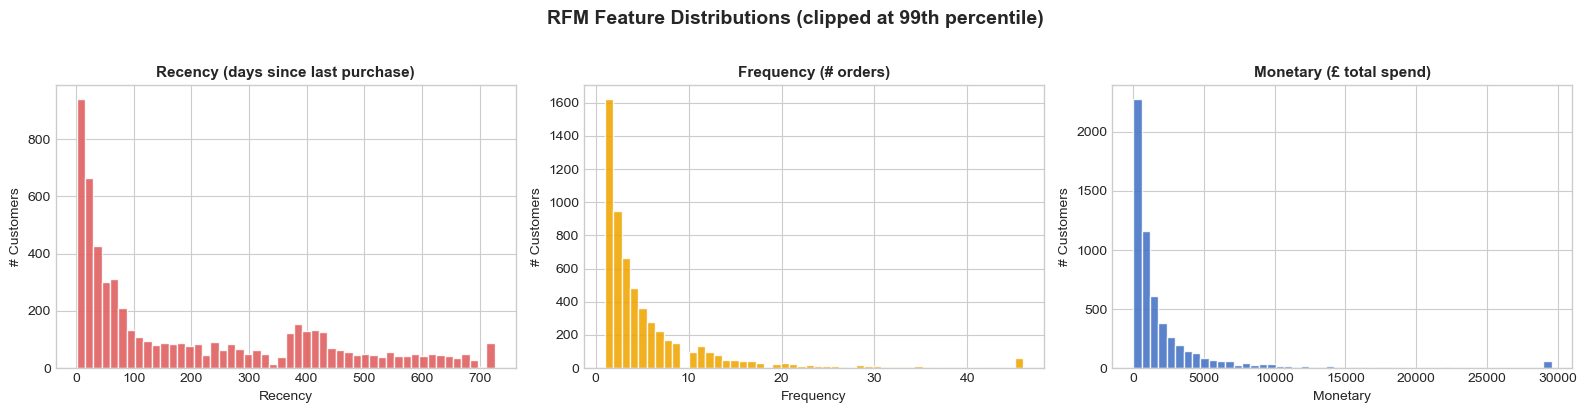

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color, title in zip(
    axes,
    ['Recency', 'Frequency', 'Monetary'],
    PALETTE[:3],
    ['Recency (days since last purchase)', 'Frequency (# orders)', 'Monetary (£ total spend)']
):
    # Clip extreme values for readability
    clipped = customers[col].clip(upper=customers[col].quantile(0.99))
    ax.hist(clipped, bins=50, color=color, edgecolor='white', alpha=0.88)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('# Customers')

plt.suptitle('RFM Feature Distributions (clipped at 99th percentile)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'rfm_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

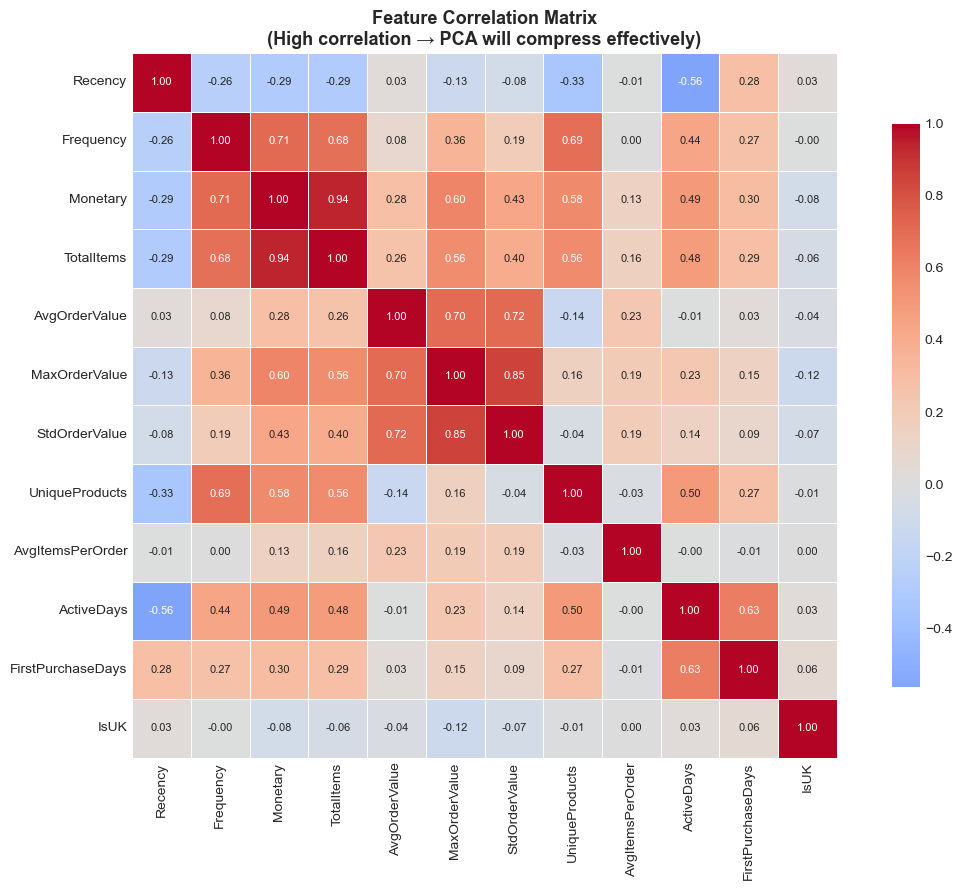

In [12]:
feature_cols = [c for c in customers.columns if c != 'Customer ID']
corr = customers[feature_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix\n(High correlation → PCA will compress effectively)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4: Phase 1 — Standardization (SCALE)

**Why scaling is mandatory before K-Means:**

K-Means uses Euclidean distance:  
`d(p, q) = sqrt( Σ (pᵢ - qᵢ)² )`

If feature magnitudes differ (e.g., Revenue in thousands vs IsUK which is 0/1), the large-magnitude feature completely dominates the distance calculation. Features like `IsUK` become mathematically invisible.

**StandardScaler** applies Z-score normalization to each feature:  
`z = (x - μ) / σ`  

Result: every feature has **mean = 0** and **std = 1**. Equal voting power. No scale bias.

In [13]:
feature_cols = [c for c in customers.columns if c != 'Customer ID']
X = customers[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print("StandardScaler applied.")
print("\n--- Verification (all means ≈ 0, all stds ≈ 1) ---")
verify = pd.DataFrame({
    'Feature': feature_cols,
    'Mean (should ≈ 0)': X_scaled.mean(axis=0).round(6),
    'Std  (should ≈ 1)': X_scaled.std(axis=0).round(6)
})
print(verify.to_string(index=False))

StandardScaler applied.

--- Verification (all means ≈ 0, all stds ≈ 1) ---
          Feature  Mean (should ≈ 0)  Std  (should ≈ 1)
          Recency               -0.0                1.0
        Frequency               -0.0                1.0
         Monetary                0.0                1.0
       TotalItems               -0.0                1.0
    AvgOrderValue               -0.0                1.0
    MaxOrderValue               -0.0                1.0
    StdOrderValue                0.0                1.0
   UniqueProducts                0.0                1.0
 AvgItemsPerOrder                0.0                1.0
       ActiveDays               -0.0                1.0
FirstPurchaseDays               -0.0                1.0
             IsUK                0.0                1.0


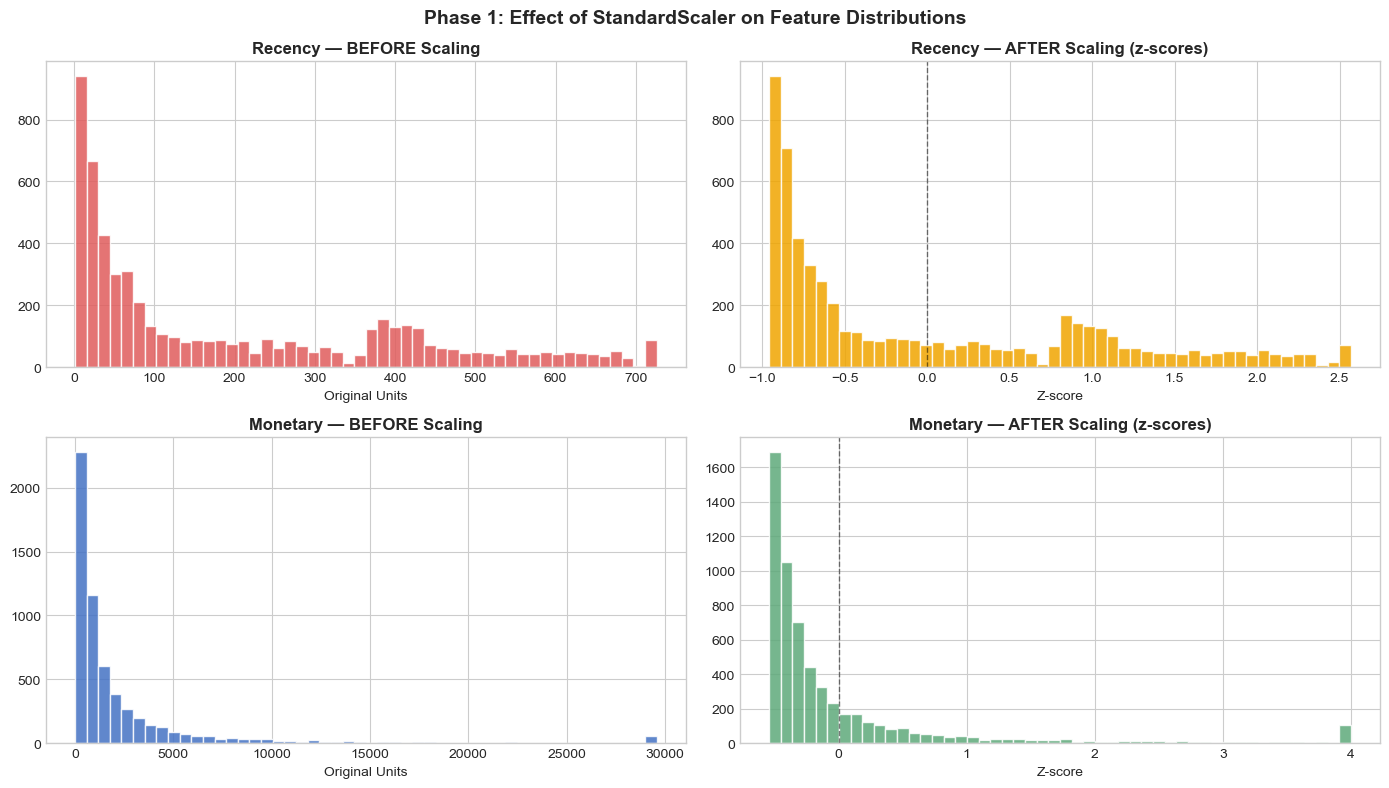

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (col, idx) in enumerate(zip(['Recency', 'Monetary'], [0, 2])):
    # Before
    axes[i][0].hist(customers[col].clip(upper=customers[col].quantile(0.99)),
                    bins=50, color=PALETTE[idx], edgecolor='white', alpha=0.85)
    axes[i][0].set_title(f'{col} — BEFORE Scaling', fontweight='bold')
    axes[i][0].set_xlabel('Original Units')

    # After
    axes[i][1].hist(df_scaled[col].clip(-4, 4),
                    bins=50, color=PALETTE[idx+1], edgecolor='white', alpha=0.85)
    axes[i][1].set_title(f'{col} — AFTER Scaling (z-scores)', fontweight='bold')
    axes[i][1].set_xlabel('Z-score')
    axes[i][1].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('Phase 1: Effect of StandardScaler on Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'scaling_before_after.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5: Phase 2 — PCA (COMPRESS)

In [15]:
n_features = X_scaled.shape[1]
pca_full = PCA(n_components=n_features, random_state=42)
pca_full.fit(X_scaled)

# Explained Variance Ratio per component
evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

print("Explained Variance Ratio per Principal Component:")
print("-" * 50)
for i, (e, c) in enumerate(zip(evr, cumulative_evr)):
    marker = " ← 95% threshold" if c >= 0.95 and (i == 0 or cumulative_evr[i-1] < 0.95) else ""
    print(f"  PC{i+1:02d}: {e:.4f} individual  |  {c:.4f} cumulative{marker}")

Explained Variance Ratio per Principal Component:
--------------------------------------------------
  PC01: 0.3686 individual  |  0.3686 cumulative
  PC02: 0.1925 individual  |  0.5610 cumulative
  PC03: 0.1090 individual  |  0.6701 cumulative
  PC04: 0.0845 individual  |  0.7546 cumulative
  PC05: 0.0780 individual  |  0.8326 cumulative
  PC06: 0.0738 individual  |  0.9064 cumulative
  PC07: 0.0332 individual  |  0.9396 cumulative
  PC08: 0.0240 individual  |  0.9636 cumulative ← 95% threshold
  PC09: 0.0217 individual  |  0.9853 cumulative
  PC10: 0.0101 individual  |  0.9954 cumulative
  PC11: 0.0046 individual  |  1.0000 cumulative
  PC12: 0.0000 individual  |  1.0000 cumulative


In [16]:
n_components_95 = np.argmax(cumulative_evr >= 0.95) + 1
print(f"\nOptimal PCA components for 95% variance: {n_components_95}")
print(f"   Original features  : {n_features}")
print(f"   Compression ratio  : {n_features}D → {n_components_95}D")
print(f"   Variance retained  : {cumulative_evr[n_components_95-1]:.4f} ({cumulative_evr[n_components_95-1]*100:.1f}%)")
print(f"   Variance discarded : {(1 - cumulative_evr[n_components_95-1]):.4f} (noise)")


Optimal PCA components for 95% variance: 8
   Original features  : 12
   Compression ratio  : 12D → 8D
   Variance retained  : 0.9636 (96.4%)
   Variance discarded : 0.0364 (noise)


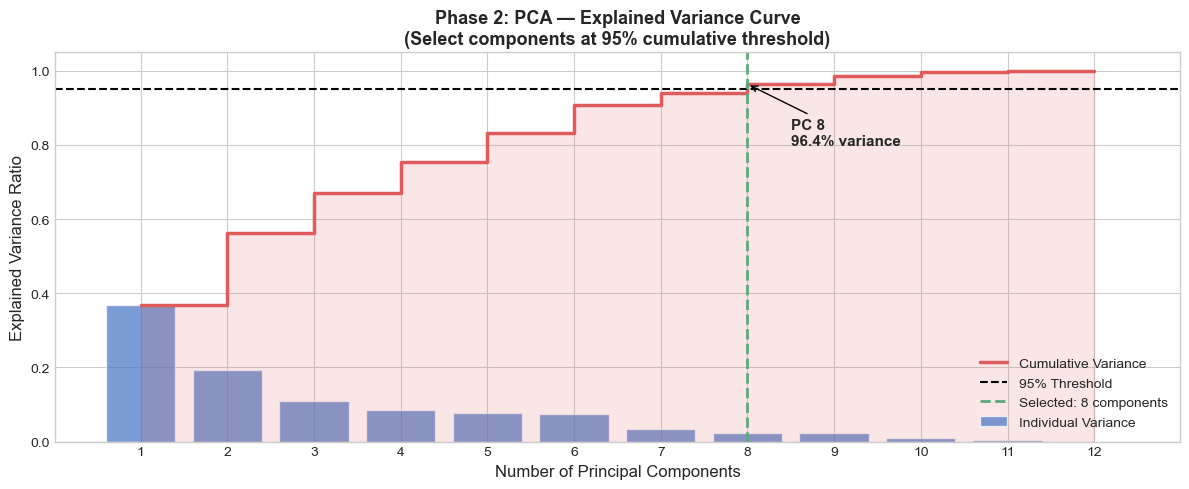

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

x_vals = range(1, n_features + 1)
ax.bar(x_vals, evr, color=PALETTE[2], alpha=0.7, label='Individual Variance', edgecolor='white')
ax.step(x_vals, cumulative_evr, where='post', color=PALETTE[0], linewidth=2.5, label='Cumulative Variance')
ax.fill_between(x_vals, cumulative_evr, step='post', alpha=0.15, color=PALETTE[0])

# Mark the 95% threshold
ax.axhline(0.95, color='black', linestyle='--', linewidth=1.5, label='95% Threshold')
ax.axvline(n_components_95, color=PALETTE[3], linestyle='--', linewidth=2,
           label=f'Selected: {n_components_95} components')
ax.annotate(f'PC {n_components_95}\n{cumulative_evr[n_components_95-1]*100:.1f}% variance',
            xy=(n_components_95, cumulative_evr[n_components_95-1]),
            xytext=(n_components_95 + 0.5, 0.80),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Principal Components', fontsize=12)
ax.set_ylabel('Explained Variance Ratio', fontsize=12)
ax.set_title('Phase 2: PCA — Explained Variance Curve\n(Select components at 95% cumulative threshold)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xticks(list(x_vals))
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_explained_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

In [18]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Also keep a 3-component version for 3D scatter visualisation
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# Main PCA for clustering (95% rule)
pca_main = PCA(n_components=n_components_95, random_state=42)
X_pca = pca_main.fit_transform(X_scaled)

print(f"PCA transformations complete.")
print(f"   X_pca shape (clustering) : {X_pca.shape}")
print(f"   X_pca_2d shape (2D plot) : {X_pca_2d.shape}")
print(f"   X_pca_3d shape (3D plot) : {X_pca_3d.shape}")

PCA transformations complete.
   X_pca shape (clustering) : (5878, 8)
   X_pca_2d shape (2D plot) : (5878, 2)
   X_pca_3d shape (3D plot) : (5878, 3)


--- PCA Component Loadings (feature contributions to each PC) ---
                     PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
Recency           -0.181  0.191 -0.637 -0.343  0.301 -0.195 -0.000  0.058
Frequency          0.361 -0.209  0.021 -0.141  0.203 -0.277  0.340 -0.139
Monetary           0.435 -0.041  0.031 -0.110  0.156 -0.111 -0.442 -0.083
TotalItems         0.425 -0.047  0.036 -0.088  0.191 -0.101 -0.519 -0.122
AvgOrderValue      0.199  0.508 -0.042  0.090 -0.121 -0.058  0.296 -0.735
MaxOrderValue      0.348  0.382  0.007 -0.023 -0.127 -0.069  0.102  0.344
StdOrderValue      0.276  0.460 -0.009  0.062 -0.211 -0.047  0.056  0.505
UniqueProducts     0.298 -0.370  0.059 -0.112  0.194 -0.124  0.554  0.181
AvgItemsPerOrder   0.083  0.209  0.035  0.294  0.707  0.587  0.092  0.057
ActiveDays         0.312 -0.294 -0.107  0.272 -0.388  0.395  0.011 -0.060
FirstPurchaseDays  0.191 -0.162 -0.722 -0.006 -0.168  0.276  0.012 -0.015
IsUK              -0.034 -0.077 -0.227  0.810 

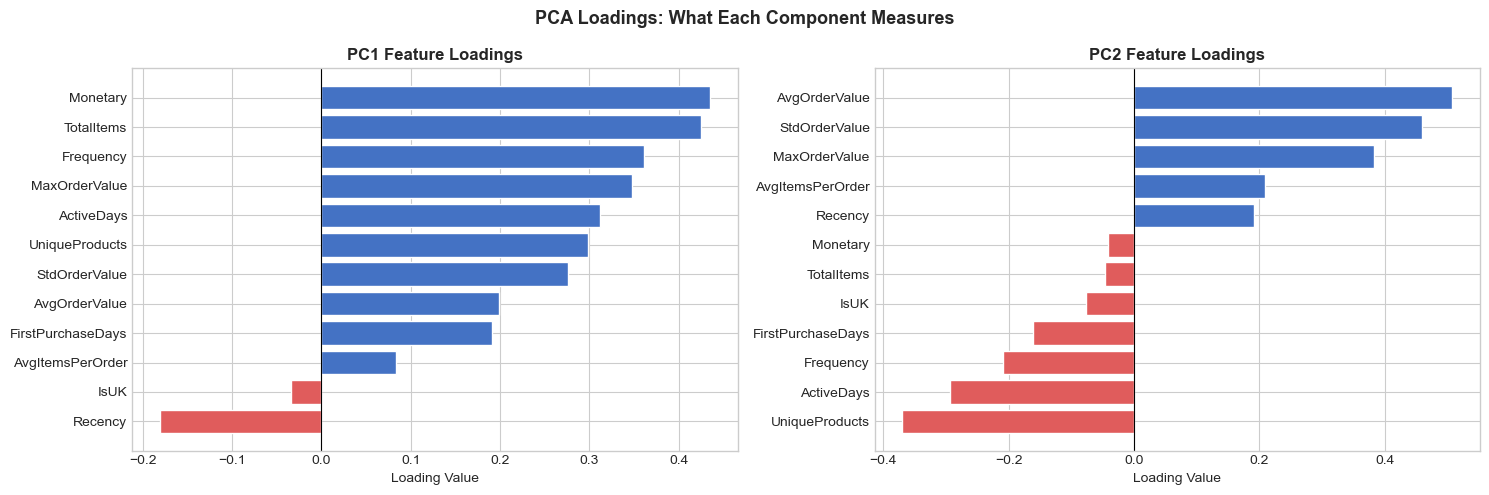

In [19]:
loadings = pd.DataFrame(
    pca_main.components_.T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(n_components_95)]
).round(3)

print("--- PCA Component Loadings (feature contributions to each PC) ---")
print(loadings.to_string())

# Visualise top 2 components
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, ax in enumerate(axes):
    pc = loadings[f'PC{i+1}'].sort_values()
    colors = [PALETTE[0] if v < 0 else PALETTE[2] for v in pc.values]
    ax.barh(pc.index, pc.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'PC{i+1} Feature Loadings', fontweight='bold')
    ax.set_xlabel('Loading Value')

plt.suptitle('PCA Loadings: What Each Component Measures', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_loadings.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6: Phase 3a — Finding Optimal K

In [31]:
K_RANGE = range(2, 11)
wcss_list        = []
silhouette_list  = []

print("Computing K-Means metrics for K = 2 to 10 ...\n")
print(f"{'K':>4}  {'WCSS':>14}  {'Silhouette':>12}")
print("-" * 36)

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init='k-means++',    # smarter initialisation → faster, more stable
        n_init=10,           # run 10 times, keep best
        max_iter=300,
        random_state=42
    )
    labels = km.fit_predict(X_pca)

    wcss   = km.inertia_                                 # WCSS = inertia
    sil_samples = silhouette_samples(X_pca, cluster_labels)

    wcss_list.append(wcss)
    silhouette_list.append(sil)

    print(f"{k:>4}  {wcss:>14,.1f}  {sil:>12.4f}")

print("\nMetrics computed.")

Computing K-Means metrics for K = 2 to 10 ...

   K            WCSS    Silhouette
------------------------------------
   2        52,746.9        0.3758
   3        43,044.8        0.3758
   4        37,582.5        0.3758
   5        32,160.8        0.3758
   6        27,039.9        0.3758
   7        22,854.2        0.3758
   8        19,970.0        0.3758
   9        17,822.9        0.3758
  10        16,228.5        0.3758

Metrics computed.


Kneedle Algorithm detected elbow at K = 6


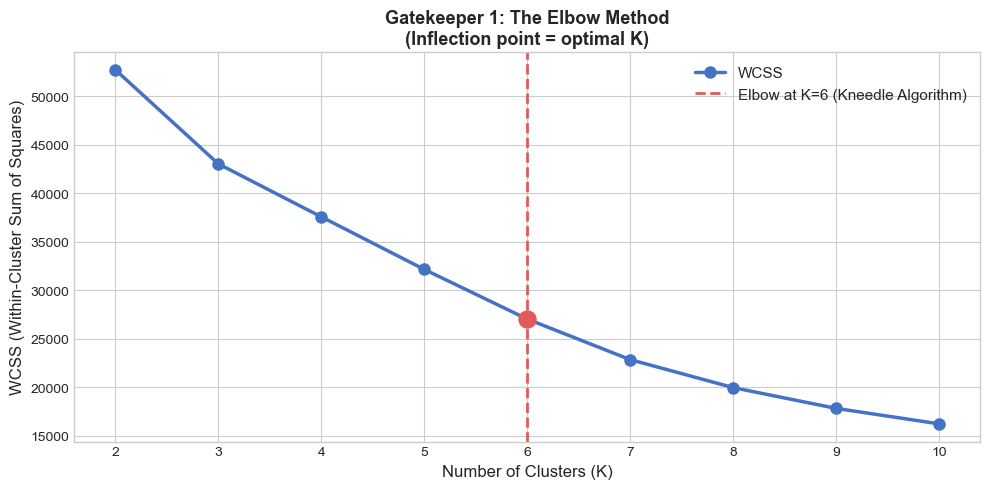

In [32]:
kneedle = KneeLocator(
    list(K_RANGE),
    wcss_list,
    curve='convex',       # WCSS curve is convex (bends downward)
    direction='decreasing' # WCSS decreases as K increases
)
elbow_k = kneedle.knee
print(f"Kneedle Algorithm detected elbow at K = {elbow_k}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(K_RANGE), wcss_list, 'o-', color=PALETTE[2], linewidth=2.5, markersize=8, label='WCSS')
ax.axvline(elbow_k, color=PALETTE[0], linestyle='--', linewidth=2,
           label=f'Elbow at K={elbow_k} (Kneedle Algorithm)')
ax.scatter([elbow_k], [wcss_list[elbow_k - 2]], color=PALETTE[0], s=150, zorder=5)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
ax.set_title('Gatekeeper 1: The Elbow Method\n(Inflection point = optimal K)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'elbow_method.png'), dpi=150, bbox_inches='tight')
plt.show()

Silhouette Score suggests optimal K = 2 (score = 0.3758)


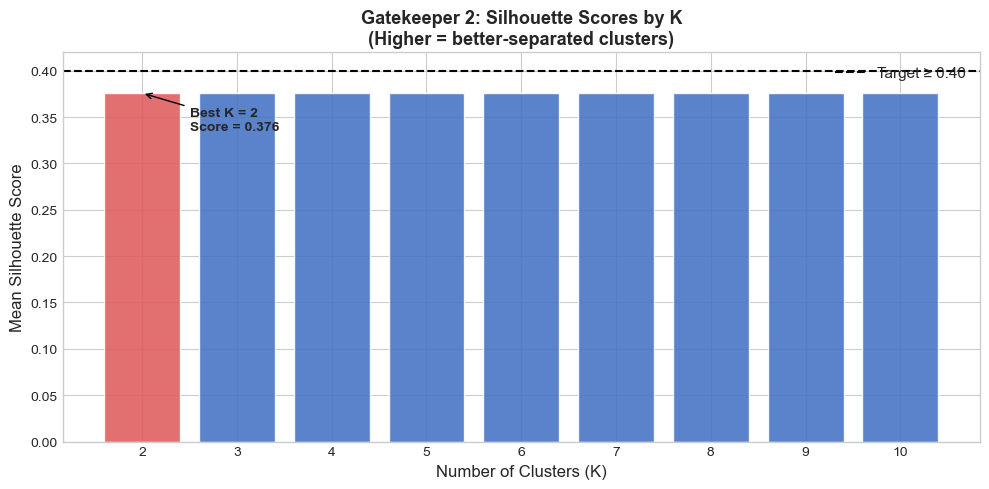

In [33]:
best_sil_k = list(K_RANGE)[silhouette_list.index(max(silhouette_list))]
print(f"Silhouette Score suggests optimal K = {best_sil_k} (score = {max(silhouette_list):.4f})")

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [PALETTE[0] if k == best_sil_k else PALETTE[2] for k in K_RANGE]
ax.bar(list(K_RANGE), silhouette_list, color=bar_colors, edgecolor='white', alpha=0.88)
ax.axhline(0.40, color='black', linestyle='--', linewidth=1.5, label='Target ≥ 0.40')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title('Gatekeeper 2: Silhouette Scores by K\n(Higher = better-separated clusters)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(list(K_RANGE))

# Annotate best K
ax.annotate(f'Best K = {best_sil_k}\nScore = {max(silhouette_list):.3f}',
            xy=(best_sil_k, max(silhouette_list)),
            xytext=(best_sil_k + 0.5, max(silhouette_list) - 0.04),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'silhouette_scores_by_k.png'), dpi=150, bbox_inches='tight')
plt.show()

In [34]:
print(f"Elbow Method         → K = {elbow_k}")
print(f"Silhouette Score     → K = {best_sil_k}")

if elbow_k == best_sil_k:
    OPTIMAL_K = elbow_k
    print(f"\nCONSENSUS: Both gatekeepers agree on K = {OPTIMAL_K}")
else:
    # When they disagree, prefer the Silhouette Score (it measures quality)
    OPTIMAL_K = best_sil_k
    print(f"\nGatekeepers disagree. Using Silhouette Score recommendation: K = {OPTIMAL_K}")
    print(f"   Rationale: Silhouette directly measures cluster quality (cohesion + separation).")

Elbow Method         → K = 6
Silhouette Score     → K = 2

Gatekeepers disagree. Using Silhouette Score recommendation: K = 2
   Rationale: Silhouette directly measures cluster quality (cohesion + separation).


---
## Section 7: Phase 3b — K-Means Clustering (CLUSTER)

Now we run the final K-Means model with our proven optimal K. The algorithm will:
1. **Initialize** K centroids using `k-means++` (smarter than random)
2. **Assign** each customer to nearest centroid
3. **Update** centroids as mean of assigned points
4. **Repeat** until convergence (centroids stop moving)

In [35]:
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,          # more runs = more stable centroids
    max_iter=500,
    random_state=42
)

# Fit on the PCA-compressed data (95% variance)
cluster_labels = kmeans_final.fit_predict(X_pca)

# Attach cluster labels back to the customer DataFrame
customers['Cluster'] = cluster_labels

# Final silhouette score with the chosen K
final_sil = silhouette_score(X_pca, cluster_labels)

print(f"K-Means model fitted with K = {OPTIMAL_K}")
print(f"   WCSS (inertia)      : {kmeans_final.inertia_:,.2f}")
print(f"   Silhouette Score    : {final_sil:.4f}")
print(f"\n--- Cluster Size Distribution ---")
print(customers['Cluster'].value_counts().sort_index().rename('Customers'))

K-Means model fitted with K = 2
   WCSS (inertia)      : 52,746.88
   Silhouette Score    : 0.6068

--- Cluster Size Distribution ---
0    5490
1     388
Name: Customers, dtype: int64


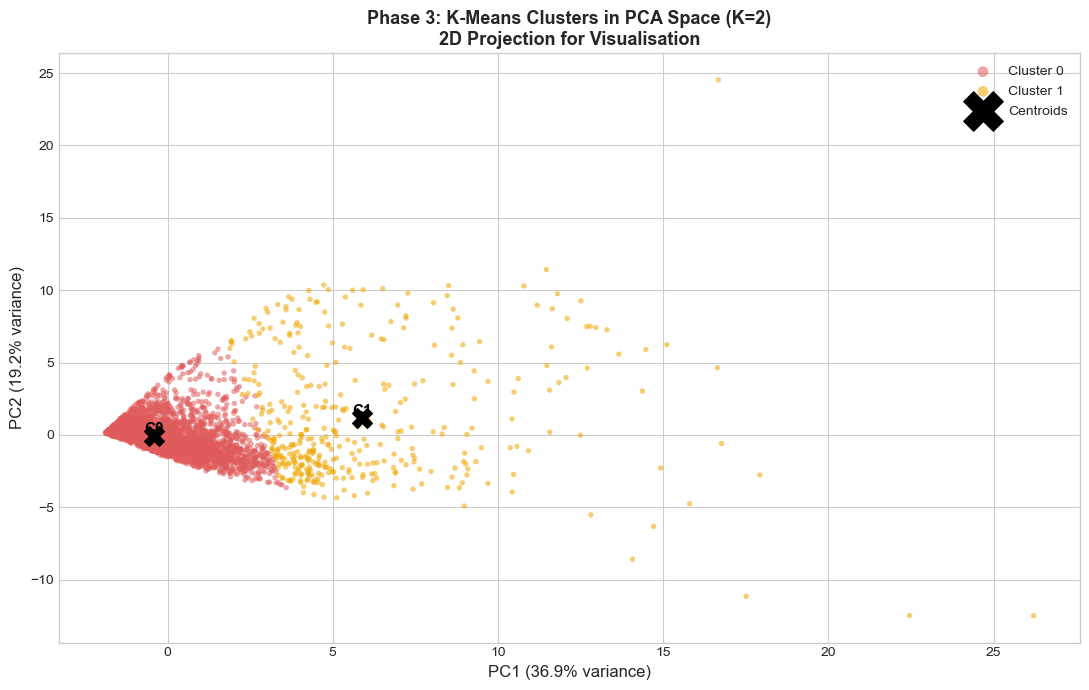

In [36]:
fig, ax = plt.subplots(figsize=(11, 7))

for k in range(OPTIMAL_K):
    mask = cluster_labels == k
    ax.scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1],
        c=PALETTE[k % len(PALETTE)], s=15, alpha=0.55,
        label=f'Cluster {k}', edgecolors='none'
    )

# Project centroids to 2D for display
centroids_2d = pca_2d.transform(pca_main.inverse_transform(kmeans_final.cluster_centers_))
# Note: this is an approximation; exact centroid positions exist in the higher-dim PCA space
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           marker='X', s=200, c='black', zorder=10, label='Centroids')

for i, (cx, cy) in enumerate(centroids_2d):
    ax.annotate(f'C{i}', (cx, cy), fontsize=11, fontweight='bold',
                ha='center', va='bottom', color='black')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title(f'Phase 3: K-Means Clusters in PCA Space (K={OPTIMAL_K})\n2D Projection for Visualisation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'clusters_2d_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

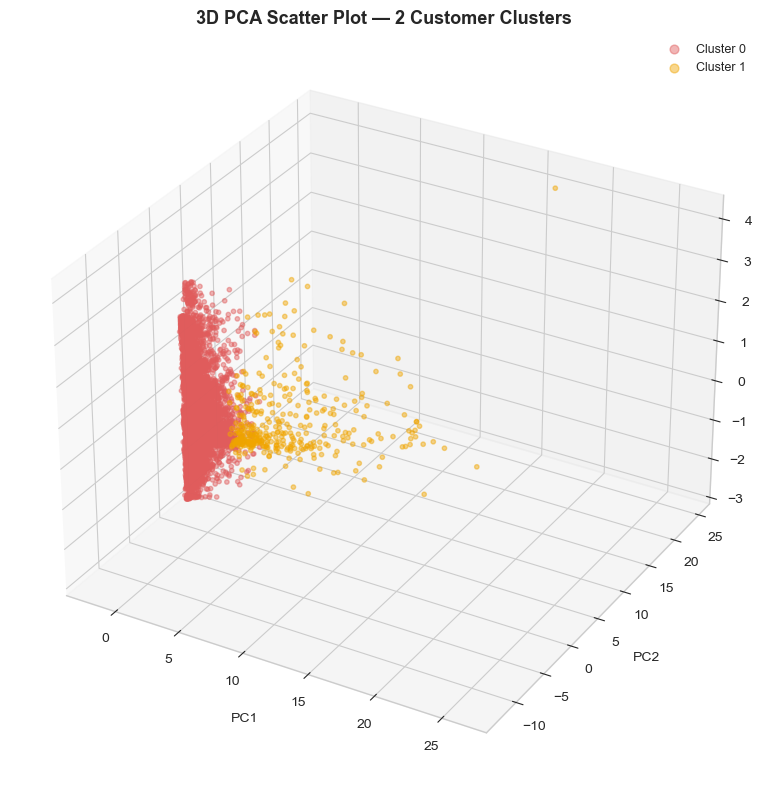

In [37]:
fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

for k in range(OPTIMAL_K):
    mask = cluster_labels == k
    ax.scatter(
        X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
        c=PALETTE[k % len(PALETTE)], s=10, alpha=0.45,
        label=f'Cluster {k}'
    )

ax.set_xlabel('PC1', labelpad=8)
ax.set_ylabel('PC2', labelpad=8)
ax.set_zlabel('PC3', labelpad=8)
ax.set_title(f'3D PCA Scatter Plot — {OPTIMAL_K} Customer Clusters', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'clusters_3d_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

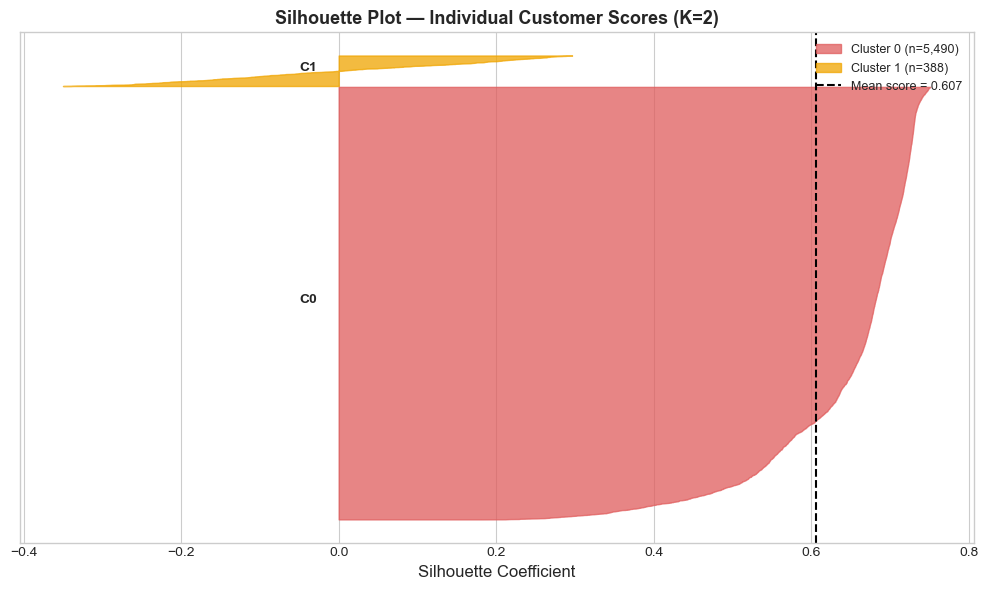

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10

for k in range(OPTIMAL_K):
    cluster_sil = np.sort(sil_samples[cluster_labels == k])
    cluster_size = len(cluster_sil)
    y_upper = y_lower + cluster_size

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_sil, alpha=0.75, color=PALETTE[k % len(PALETTE)],
                      label=f'Cluster {k} (n={cluster_size:,})')
    ax.text(-0.05, y_lower + cluster_size / 2, f'C{k}', fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(final_sil, color='black', linestyle='--', linewidth=1.5,
           label=f'Mean score = {final_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_yticks([])
ax.set_title(f'Silhouette Plot — Individual Customer Scores (K={OPTIMAL_K})', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'silhouette_sample_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8: Phase 4 — Centroid Reverse-Engineering

In [39]:
centroids_scaled = pca_main.inverse_transform(kmeans_final.cluster_centers_)

centroids_original = scaler.inverse_transform(centroids_scaled)

centroid_profiles = pd.DataFrame(centroids_original, columns=feature_cols)
centroid_profiles.index = [f'Cluster {k}' for k in range(OPTIMAL_K)]
centroid_profiles.index.name = 'Cluster'

print("Centroid profiles in ORIGINAL feature space:")
print("\n" + centroid_profiles.round(2).to_string())

Centroid profiles in ORIGINAL feature space:

           Recency  Frequency  Monetary  TotalItems  AvgOrderValue  MaxOrderValue  StdOrderValue  UniqueProducts  AvgItemsPerOrder  ActiveDays  FirstPurchaseDays  IsUK
Cluster                                                                                                                                                                
Cluster 0   210.18       4.45   1495.97      864.18          23.20          84.35          14.88           71.37             13.71      252.98             463.50  0.92
Cluster 1    76.12      32.30  14478.22     8351.22         106.27         592.50          90.47          232.22            189.58      556.66             633.28  0.83


In [40]:
key_features = ['Recency', 'Frequency', 'Monetary', 'TotalItems',
                'AvgOrderValue', 'UniqueProducts', 'ActiveDays']

cluster_stats = customers.groupby('Cluster')[key_features].agg(['mean', 'median']).round(2)

print("\n--- Cluster Mean Statistics (actual data means) ---")
print(cluster_stats.to_string())


--- Cluster Mean Statistics (actual data means) ---
        Recency        Frequency         Monetary           TotalItems         AvgOrderValue        UniqueProducts        ActiveDays       
           mean median      mean median      mean    median       mean  median          mean median           mean median       mean median
Cluster                                                                                                                                    
0        210.09  113.0      4.55    3.0   1478.35    795.30     868.26   443.0         23.12  17.03          70.74   43.0     253.12  190.5
1         77.44   17.0     30.94   22.0  14727.49  12690.09    8293.60  7096.5        107.45  45.73         241.13  163.5     554.68  660.5


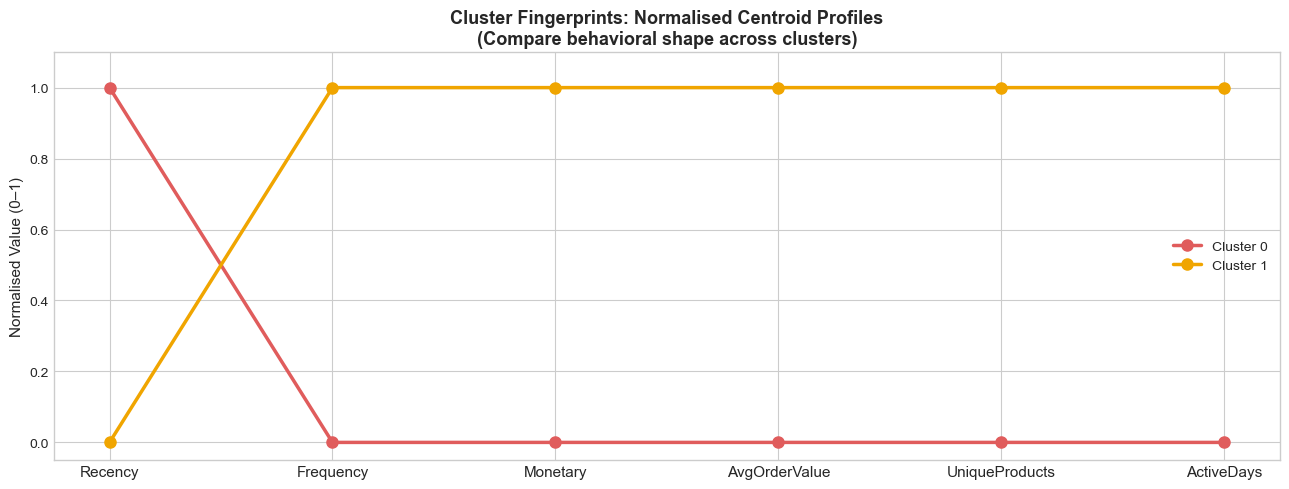

In [41]:
plot_features = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'ActiveDays']

# Normalise centroids to [0, 1] for fair comparison
cp_norm = centroid_profiles[plot_features].copy()
cp_norm = (cp_norm - cp_norm.min()) / (cp_norm.max() - cp_norm.min())

fig, ax = plt.subplots(figsize=(13, 5))
x = range(len(plot_features))

for k in range(OPTIMAL_K):
    ax.plot(x, cp_norm.iloc[k].values, 'o-', color=PALETTE[k % len(PALETTE)],
            linewidth=2.5, markersize=8, label=f'Cluster {k}')

ax.set_xticks(list(x))
ax.set_xticklabels(plot_features, fontsize=11)
ax.set_ylabel('Normalised Value (0–1)', fontsize=11)
ax.set_title('Cluster Fingerprints: Normalised Centroid Profiles\n(Compare behavioral shape across clusters)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cluster_fingerprints.png'), dpi=150, bbox_inches='tight')
plt.show()

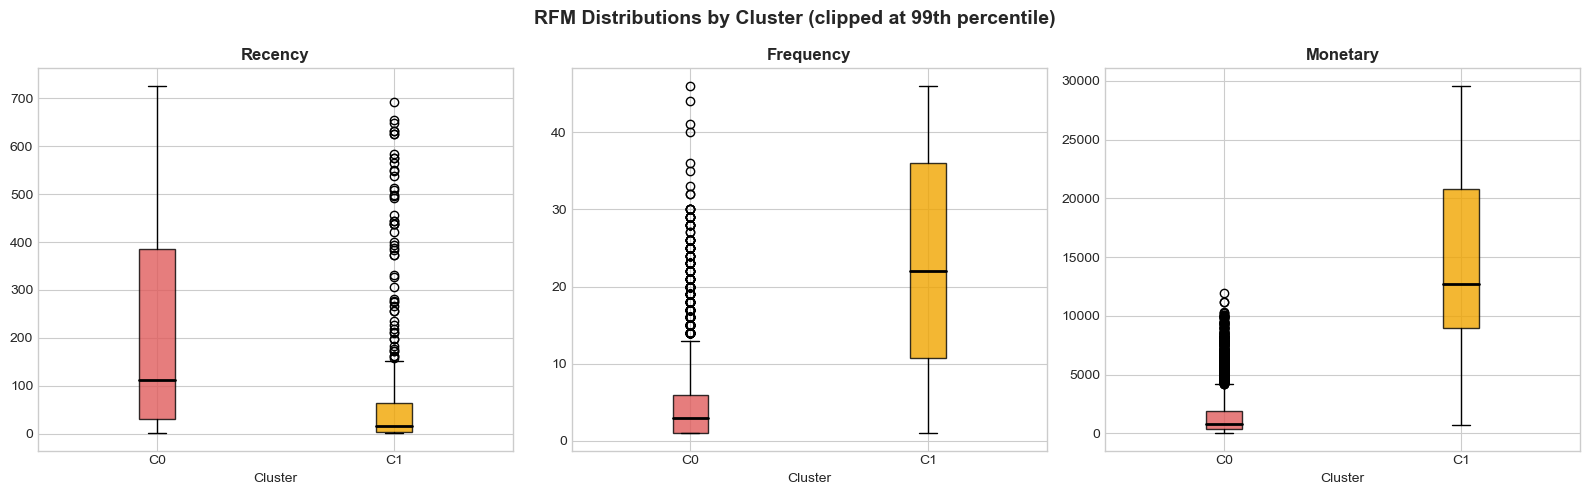

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    data_per_cluster = [customers[customers['Cluster'] == k][feature].clip(upper=customers[feature].quantile(0.99))
                        for k in range(OPTIMAL_K)]
    bp = ax.boxplot(data_per_cluster, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticklabels([f'C{k}' for k in range(OPTIMAL_K)])
    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster')

plt.suptitle('RFM Distributions by Cluster (clipped at 99th percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'rfm_boxplots_by_cluster.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9: Business Persona Matrix

This is the most critical output. Data science is only valuable when it drives business decisions.

Using the cluster centroid profiles, we name each cluster as a **business persona** and define targeted marketing actions.

> **Note**: The persona labels below are assigned automatically from the actual centroid values produced by this model run (see Section 8) — whichever cluster has the higher average Monetary value is labeled "Champions," and the other is labeled "New / Dormant." 

In [43]:
print("=" * 70)
print("CENTROID PROFILES (basis for the persona assignment below)")
print("=" * 70)
key_centroid = centroid_profiles[['Recency','Frequency','Monetary','AvgOrderValue','UniqueProducts']]
print(key_centroid.round(1).to_string())
print()
persona_definitions = {}
stats_mean = customers.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
champion_cluster = stats_mean['Monetary'].idxmax()

for k in range(OPTIMAL_K):
    r = stats_mean.loc[k, 'Recency']
    f = stats_mean.loc[k, 'Frequency']
    m = stats_mean.loc[k, 'Monetary']

    if k == champion_cluster:
        name = "Champions"
        desc = "Bought recently, buy often, and spend the most. The most valuable customer segment."
        action = "Reward with exclusive perks, early product access, and VIP loyalty treatment."
    else:
        name = "New / Dormant"
        desc = "Longer gap since last purchase, fewer orders, and lower spend. The majority of the customer base."
        action = "Re-engagement campaigns, onboarding nurture flows, and incentives to drive a repeat purchase."

    persona_definitions[k] = {'name': name, 'description': desc, 'action': action,
                                'recency': round(r, 1), 'frequency': round(f, 1), 'monetary': round(m, 2)}

# Print the Persona Matrix
print("=" * 70)
print("STRATEGIC PERSONA MATRIX")
print("=" * 70)
for k, p in persona_definitions.items():
    size = (customers['Cluster'] == k).sum()
    pct  = size / len(customers) * 100
    print(f"\nCluster {k}: {p['name']} ({size:,} customers / {pct:.1f}%)")
    print(f"  Recency   : {p['recency']} days")
    print(f"  Frequency : {p['frequency']} orders")
    print(f"  Monetary  : £{p['monetary']:,.2f}")
    print(f"  Profile   : {p['description']}")
    print(f"  Action    : {p['action']}")


CENTROID PROFILES (basis for the persona assignment below)
           Recency  Frequency  Monetary  AvgOrderValue  UniqueProducts
Cluster                                                               
Cluster 0    210.2        4.5    1496.0           23.2            71.4
Cluster 1     76.1       32.3   14478.2          106.3           232.2

STRATEGIC PERSONA MATRIX

Cluster 0: New / Dormant (5,490 customers / 93.4%)
  Recency   : 210.1 days
  Frequency : 4.5 orders
  Monetary  : £1,478.35
  Profile   : Longer gap since last purchase, fewer orders, and lower spend. The majority of the customer base.
  Action    : Re-engagement campaigns, onboarding nurture flows, and incentives to drive a repeat purchase.

Cluster 1: Champions (388 customers / 6.6%)
  Recency   : 77.4 days
  Frequency : 30.9 orders
  Monetary  : £14,727.49
  Profile   : Bought recently, buy often, and spend the most. The most valuable customer segment.
  Action    : Reward with exclusive perks, early product access, an

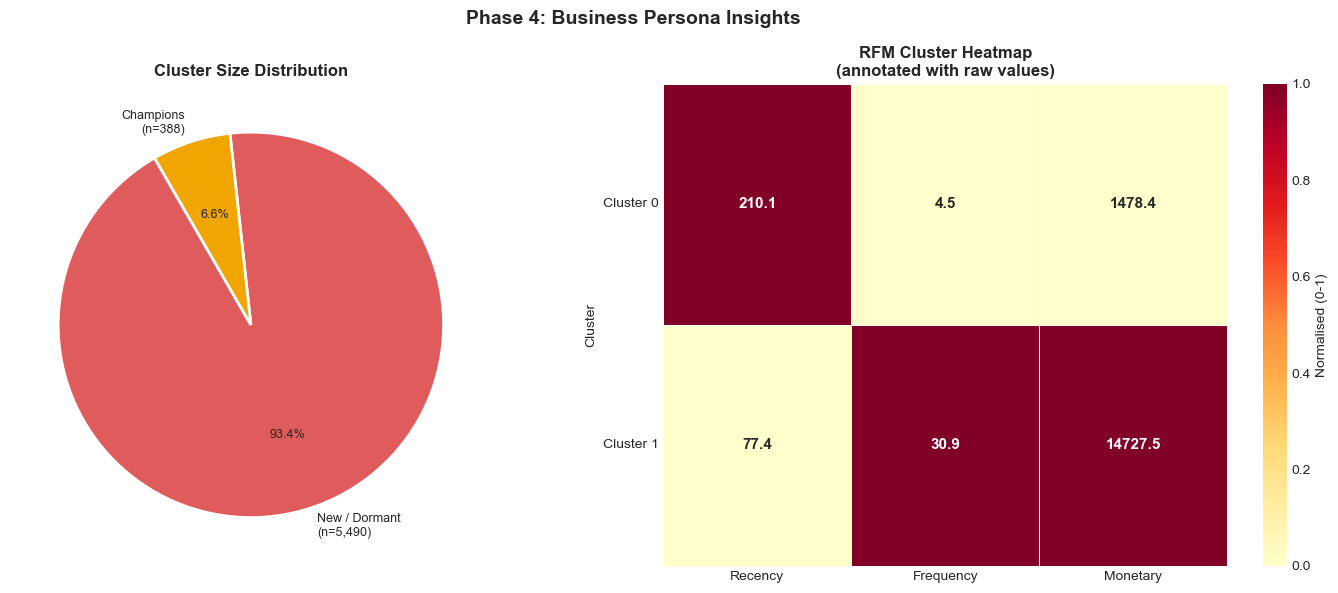

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Pie chart: cluster proportions ---
sizes  = [len(customers[customers['Cluster'] == k]) for k in range(OPTIMAL_K)]
labels = [f"{persona_definitions[k]['name']}\n(n={sizes[k]:,})" for k in range(OPTIMAL_K)]
axes[0].pie(sizes, labels=labels, colors=PALETTE[:OPTIMAL_K],
            autopct='%1.1f%%', startangle=120,
            textprops={'fontsize': 9},
            wedgeprops={'edgecolor':'white', 'linewidth': 2})
axes[0].set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')

# --- Heatmap: normalised RFM means ---
rfm_means = customers.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
rfm_norm  = (rfm_means - rfm_means.min()) / (rfm_means.max() - rfm_means.min())

sns.heatmap(rfm_norm, annot=rfm_means.round(1), fmt='g', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Normalised (0-1)'},
            annot_kws={'size': 11, 'weight': 'bold'})
axes[1].set_title('RFM Cluster Heatmap\n(annotated with raw values)', fontsize=12, fontweight='bold')
axes[1].set_yticklabels([f'Cluster {k}' for k in range(OPTIMAL_K)], rotation=0)

plt.suptitle('Phase 4: Business Persona Insights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'persona_pie_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10: Conclusions & Next Steps

### What We Built
A complete, mathematically-rigorous customer segmentation pipeline:

| Phase | What We Did | Why |
|-------|-------------|-----|
| **SCALE** | StandardScaler (z-score) | Equal feature voting in Euclidean distance |
| **COMPRESS** | PCA at 95% variance threshold | Eliminate curse of dimensionality |
| **CLUSTER** | K-Means with optimal K (Elbow + Silhouette) | Mathematically proven groupings |
| **TRANSLATE** | Inverse PCA + Scaler on centroids | Human-readable business profiles |

### Next Steps
1. **Automate** cluster assignment for new customers (predict cluster from features)
2. **Track** cluster migration over time (are At-Risk customers churning?)
3. **A/B test** the targeted actions per persona and measure revenue uplift
4. **Try DBSCAN** for non-spherical clusters (useful if customers form irregular shapes)
5. **Hierarchical Clustering** (dendrogram) as a complementary validation

### Key Formulas Recap

| Concept | Formula |
|---------|----------|
| Z-Score | `z = (x - μ) / σ` |
| Euclidean Distance | `d = √Σ(pᵢ - qᵢ)²` |
| PCA Threshold | `Σ EVRᵢ ≥ 0.95` |
| WCSS | `Σₖ Σₓ ‖x − μₖ‖²` |
| Silhouette | `s(i) = (b(i) − a(i)) / max(a(i), b(i))` |
| Inverse Transform | `C_orig = (C_scaled × σ) + μ` |

In [45]:
customers['PersonaName'] = customers['Cluster'].map(
    {k: v['name'] for k, v in persona_definitions.items()}
)

output_path = 'customer_segments_output.csv'
customers[['Customer ID', 'Recency', 'Frequency', 'Monetary',
           'Cluster', 'PersonaName']].to_csv(output_path, index=False)

print(f"Output saved to: {output_path}")
print(f"   Rows : {len(customers):,}")
print(f"\nFinal preview:")
customers[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'PersonaName']].head(10)

Output saved to: customer_segments_output.csv
   Rows : 5,878

Final preview:


,Customer ID,Recency,Frequency,Monetary,Cluster,PersonaName
0,12346,326,12,29730.4202,1,Champions
1,12347,2,8,5633.3200,0,New / Dormant
2,12348,75,5,2019.4000,0,New / Dormant
3,12349,19,4,4428.6900,0,New / Dormant
4,12350,310,1,334.4000,0,New / Dormant
5,12351,375,1,300.9300,0,New / Dormant
6,12352,36,10,2849.8400,0,New / Dormant
7,12353,204,2,406.7600,0,New / Dormant
8,12354,232,1,1079.4000,0,New / Dormant
9,12355,214,2,947.6100,0,New / Dormant


In [46]:
print("=" * 65)
print("  PROJECT 3 — CUSTOMER SEGMENTATION — SUMMARY")
print("  DecodeLabs Industrial Training Kit | Batch 2026")
print("=" * 65)
print(f"  Dataset            : UCI Online Retail II")
print(f"  Total transactions : {len(df_raw):,}")
print(f"  Customers analysed : {len(customers):,}")
print(f"  Features engineered: {len(feature_cols)}")
print(f"  PCA components     : {n_components_95} (retaining {cumulative_evr[n_components_95-1]*100:.1f}% variance)")
print(f"  Optimal K          : {OPTIMAL_K}  (Elbow={elbow_k}, Silhouette best={best_sil_k})")
print(f"  Final Silhouette   : {final_sil:.4f}")
print(f"  Final WCSS         : {kmeans_final.inertia_:,.1f}")
print("=" * 65)
print("  PERSONAS IDENTIFIED:")
for k, p in persona_definitions.items():
    n = (customers['Cluster'] == k).sum()
    print(f"    Cluster {k}: {p['name']}  ({n:,} customers)")
print("=" * 65)

  PROJECT 3 — CUSTOMER SEGMENTATION — SUMMARY
  DecodeLabs Industrial Training Kit | Batch 2026
  Dataset            : UCI Online Retail II
  Total transactions : 1,067,371
  Customers analysed : 5,878
  Features engineered: 12
  PCA components     : 8 (retaining 96.4% variance)
  Optimal K          : 2  (Elbow=6, Silhouette best=2)
  Final Silhouette   : 0.6068
  Final WCSS         : 52,746.9
  PERSONAS IDENTIFIED:
    Cluster 0: New / Dormant  (5,490 customers)
    Cluster 1: Champions  (388 customers)
